In [9]:
import cobra
import pandas as pd
from cobra.io import load_model
from cobra.io import load_json_model, save_json_model, load_matlab_model, save_matlab_model, read_sbml_model, write_sbml_model
from cobra import Model, Reaction, Metabolite, Gene
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


## Data extraction

In [53]:
# open excel file containing the identifiers list\n
file_path ='C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.13 Biolog_data\\\\240927_Metabolite_identifier.xlsx'
metabolite_data = pd.read_excel(file_path)

In [54]:
# extract identifier of the plate PM01\n",
metabolite_df = metabolite_data[metabolite_data['Plate'].isin(['PM02A'])]
metabolite_df

,Plate,Location,Chemical,CAS ID,KEGG ID,MoA
96,PM02A,A01,Negative Control,Negative Control,NaN,"C-Source, negative control"
97,PM02A,A02,Chondroitin Sulfate C,CAS 12678-07-8,C00635,"C-Source, polymer"
98,PM02A,A03,a-Cyclodextrin,CAS 10016-20-3,NaN,"C-Source, polymer"
99,PM02A,A04,b-Cyclodextrin,CAS 7585-39-9,NaN,"C-Source, polymer"
100,PM02A,A05,g-Cyclodextrin,CAS 17465-86-0,NaN,"C-Source, polymer"
...,...,...,...,...,...,...
187,PM02A,H08,Putrescine,CAS 333-93-7,C00134,"C-Source, amine"
188,PM02A,H09,Dihydroxyacetone,CAS 96-26-4,C00184,"C-Source, alcohol"
189,PM02A,H10,"2,3-Butanediol",CAS 513-85-9,C03044,"C-Source, alcohol"
190,PM02A,H11,"2,3-Butanedione",CAS 431-03-8,C00741,"C-Source, alcohol"


In [55]:
# open excel file containing the OD600 values list\n
file_path ='C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.13 Biolog_data\\\\241016_Biolog_OD_plate_2.xlsx'
biolog_data = pd.read_excel(file_path)
biolog_data

,A1,B1,C1,D1,E1,F1,G1,H1,A2,B2,...,G11,H11,A12,B12,C12,D12,E12,F12,G12,H12
0,0.237,0.207,0.227,0.214,0.439,0.514,0.251,0.215,0.333,0.243,...,0.199,0.219,0.253,0.589,0.335,1.198,0.623,0.221,0.204,0.25


In [56]:
# Create a dictionary with only OD values above the threshold
filtered_dict = {col: biolog_data[col].tolist() 
                 for col in biolog_data.columns }
print(filtered_dict)

{'A1': [0.237], 'B1': [0.207], 'C1': [0.227], 'D1': [0.214], 'E1': [0.439], 'F1': [0.514], 'G1': [0.251], 'H1': [0.215], 'A2': [0.333], 'B2': [0.243], 'C2': [0.23], 'D2': [0.206], 'E2': [0.346], 'F2': [0.71], 'G2': [0.273], 'H2': [0.208], 'A3': [0.221], 'B3': [0.273], 'C3': [0.217], 'D3': [0.231], 'E3': [0.232], 'F3': [0.365], 'G3': [0.229], 'H3': [0.246], 'A4': [0.249], 'B4': [0.208], 'C4': [0.232], 'D4': [0.339], 'E4': [0.615], 'F4': [0.331], 'G4': [0.211], 'H4': [0.237], 'A5': [0.206], 'B5': [0.536], 'C5': [0.214], 'D5': [0.218], 'E5': [0.712], 'F5': [0.576], 'G5': [0.484], 'H5': [0.21], 'A6': [0.26], 'B6': [0.228], 'C6': [0.24], 'D6': [0.399], 'E6': [0.184], 'F6': [0.221], 'G6': [0.208], 'H6': [0.233], 'A7': [0.266], 'B7': [0.24], 'C7': [0.247], 'D7': [0.242], 'E7': [0.182], 'F7': [0.23], 'G7': [0.22], 'H7': [0.234], 'A8': [0.23], 'B8': [0.218], 'C8': [0.214], 'D8': [0.221], 'E8': [1.619], 'F8': [0.908], 'G8': [0.216], 'H8': [0.26], 'A9': [0.291], 'B9': [0.494], 'C9': [0.223], 'D9'

In [57]:
# Create a new dictionary with updated keys that contain an additional zero for single digits
updated_dict = {}

for key, value in filtered_dict.items():
    # Split the letter and the number part of the key
    letter = key[0]
    number = key[1:]
    
    # Check if the number is a single digit and add a leading zero if necessary
    if len(number) == 1:
        number = '0' + number
    
    # Recreate the key with the letter and the updated number
    new_key = letter + number
    
    # Add the new key and its value to the updated dictionary
    updated_dict[new_key] = value

# Print the updated dictionary
updated_dict

{'A01': [0.237],
 'B01': [0.207],
 'C01': [0.227],
 'D01': [0.214],
 'E01': [0.439],
 'F01': [0.514],
 'G01': [0.251],
 'H01': [0.215],
 'A02': [0.333],
 'B02': [0.243],
 'C02': [0.23],
 'D02': [0.206],
 'E02': [0.346],
 'F02': [0.71],
 'G02': [0.273],
 'H02': [0.208],
 'A03': [0.221],
 'B03': [0.273],
 'C03': [0.217],
 'D03': [0.231],
 'E03': [0.232],
 'F03': [0.365],
 'G03': [0.229],
 'H03': [0.246],
 'A04': [0.249],
 'B04': [0.208],
 'C04': [0.232],
 'D04': [0.339],
 'E04': [0.615],
 'F04': [0.331],
 'G04': [0.211],
 'H04': [0.237],
 'A05': [0.206],
 'B05': [0.536],
 'C05': [0.214],
 'D05': [0.218],
 'E05': [0.712],
 'F05': [0.576],
 'G05': [0.484],
 'H05': [0.21],
 'A06': [0.26],
 'B06': [0.228],
 'C06': [0.24],
 'D06': [0.399],
 'E06': [0.184],
 'F06': [0.221],
 'G06': [0.208],
 'H06': [0.233],
 'A07': [0.266],
 'B07': [0.24],
 'C07': [0.247],
 'D07': [0.242],
 'E07': [0.182],
 'F07': [0.23],
 'G07': [0.22],
 'H07': [0.234],
 'A08': [0.23],
 'B08': [0.218],
 'C08': [0.214],
 'D08'

In [58]:
# Create a DataFrame containing the location, chemical name, OD, and KEGG_ID
df_data = {'Location': [], 'Chemical_name': [], 'OD': [], 'KEGG_ID': []}
biolog_df = pd.DataFrame(df_data)

# Print the DataFrame
biolog_df

,Location,Chemical_name,OD,KEGG_ID


In [60]:
# Create an empty list to store the rows
rows_list = []

# Iterate over the updated_dict and build the rows
for key in updated_dict:
    row = {
        'Location': key,
        'OD': updated_dict[key][0],
        'Chemical_name': metabolite_df.loc[metabolite_df['Location'] == key, 'Chemical'].values[0],
        'KEGG_ID': metabolite_df.loc[metabolite_df['Location'] == key, 'KEGG ID'].values[0]
    }
    rows_list.append(row)

# Convert the list of rows into a DataFrame
biolog_df = pd.DataFrame(rows_list)

# Print the DataFrame
print(biolog_df)

   Location     OD             Chemical_name KEGG_ID
0       A01  0.237          Negative Control     NaN
1       B01  0.207  N-Acetyl-D-Galactosamine  C01132
2       C01  0.227               Gentiobiose  C08240
3       D01  0.214               D-Raffinose  C00492
4       E01  0.439               Capric acid  C01571
..      ...    ...                       ...     ...
91      D12  1.198              Butyric acid  C00246
92      E12  0.623    5-Keto-D-Gluconic acid  C01062
93      F12  0.221           L-Tartaric acid  C00898
94      G12  0.204              L-Methionine  C00073
95      H12  0.250      3-Hydroxy-2-butanone  C00466

[96 rows x 4 columns]


In [ ]:
biolog_df.to_excel('C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.13 Biolog_data\\\\biolog_df.xlsx', index=False)

### Addition of bigg ids to dataframe

In [61]:
model = read_sbml_model('C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.09 Models\\\\Manual_curation\\\\Biomass_equation\\\\GAM_NGAM_update.sbml')

In [62]:
# Create a new column 'BIGG_ID' in biolog_df to store concatenated results
biolog_df['BIGG_ID'] = None  # Initialize with None values

# Iterate over metabolites in the model and update biolog_df with the corresponding bigg_ID
for index, kegg_code in biolog_df['KEGG_ID'].items():
    bigg_ids = []  # Initialize an empty list to store all matching bigg_IDs
    for metabolite in model.metabolites:
        # Check if the metabolite has a 'kegg.compound' annotation
        if 'kegg.compound' in metabolite.annotation:
            kegg_annotation = metabolite.annotation['kegg.compound']
            
            # If the annotation is a list, check if kegg_code is in the list
            if isinstance(kegg_annotation, list) and kegg_code in kegg_annotation:
                bigg_ids.append(metabolite.id)
            # If it's a string, just check for equality
            elif isinstance(kegg_annotation, str) and kegg_annotation == kegg_code:
                bigg_ids.append(metabolite.id)

    # Store the concatenated bigg_IDs as a string in biolog_df
    if bigg_ids:
        biolog_df.at[index, 'BIGG_ID'] = ', '.join(bigg_ids)

# Display the updated biolog_df
print(biolog_df)

   Location     OD             Chemical_name KEGG_ID  \
0       A01  0.237          Negative Control     NaN   
1       B01  0.207  N-Acetyl-D-Galactosamine  C01132   
2       C01  0.227               Gentiobiose  C08240   
3       D01  0.214               D-Raffinose  C00492   
4       E01  0.439               Capric acid  C01571   
..      ...    ...                       ...     ...   
91      D12  1.198              Butyric acid  C00246   
92      E12  0.623    5-Keto-D-Gluconic acid  C01062   
93      F12  0.221           L-Tartaric acid  C00898   
94      G12  0.204              L-Methionine  C00073   
95      H12  0.250      3-Hydroxy-2-butanone  C00466   

                         BIGG_ID  
0                           None  
1                           None  
2                           None  
3             raffin_c, raffin_e  
4                           None  
..                           ...  
91                          None  
92                      5dglcn_c  
93          

### Addition of exchange reaction id to dataframe

In [63]:
# Iterate over each element in biolog_df.BIGG_ID
for index, element in biolog_df['BIGG_ID'].items():
    
    # Skip if element is None
    if element is None:
        continue
    
    # Check if the element is a string, and if so, split it by commas
    if isinstance(element, str):
        bigg_ids = element.split(', ')
    else:
        bigg_ids = element  # If it's already a list, keep it as is
    
    # List to store the exchange reactions for this row
    exchange_reactions = []
    
    # Iterate over each metabolite ID in the bigg_ids list
    for met in bigg_ids:
        if '_e' in met:  # Only process metabolites with '_e'
            metabolite = model.metabolites.get_by_id(met)
            related_reactions = list(metabolite.reactions)
            # Iterate over the related reactions
            for reaction in related_reactions:
                if 'EX_' in reaction.id:  # If the reaction ID contains 'EX_'
                    exchange_reactions.append(reaction.id)
    
    # If there are any exchange reactions, store them in the DataFrame
    if exchange_reactions:
        biolog_df.at[index, 'model_exchange_reaction'] = ', '.join(exchange_reactions)

# Display the updated biolog_df
print(biolog_df)

   Location     OD             Chemical_name KEGG_ID  \
0       A01  0.237          Negative Control     NaN   
1       B01  0.207  N-Acetyl-D-Galactosamine  C01132   
2       C01  0.227               Gentiobiose  C08240   
3       D01  0.214               D-Raffinose  C00492   
4       E01  0.439               Capric acid  C01571   
..      ...    ...                       ...     ...   
91      D12  1.198              Butyric acid  C00246   
92      E12  0.623    5-Keto-D-Gluconic acid  C01062   
93      F12  0.221           L-Tartaric acid  C00898   
94      G12  0.204              L-Methionine  C00073   
95      H12  0.250      3-Hydroxy-2-butanone  C00466   

                         BIGG_ID model_exchange_reaction  
0                           None                     nan  
1                           None                     nan  
2                           None                     nan  
3             raffin_c, raffin_e             EX_raffin_e  
4                           None

## Addition of reaction to the model

In [65]:
model = read_sbml_model('C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.09 Models\\Manual_curation\\Biolog\\241009_updated_exchange.sbml')

set the reactions bounds to zero to reset the medium

In [96]:
# List of metabolites to simulate yeast extract and M9 minimal medium with biolog component
yeast_extract_components = [
    'EX_ala__L_e',  # L-alanine
    'EX_arg__L_e',  # L-arginine
    'EX_asp__L_e',  # L-aspartate
    'EX_glu__L_e',  # L-glutamate
    'EX_his__L_e',  # L-histidine
    'EX_ile__L_e',  # L-isoleucine
    'EX_leu__L_e',  # L-leucine
    'EX_lys__L_e',  # L-lysine
    'EX_met__L_e',  # L-methionine
    'EX_phe__L_e',  # L-phenylalanine
    'EX_ser__L_e',  # L-serine
    'EX_thr__L_e',  # L-threonine
    'EX_trp__L_e',  # L-tryptophan
    'EX_val__L_e',  # L-valine
    'EX_btn_e',     # Biotin
    'EX_thm_e',     # Thiamin
    'EX_nac_e',     # Nicotinate (Niacin)
    'EX_pnto__R_e', # Pantothenate
    'EX_ribflv_e',  # Riboflavin
    'EX_ade_e',     # Adenine
    'EX_gua_e',     # Guanine
    'EX_ura_e',     # Uracil
    'EX_cys_e',     # Cytosine
    'EX_mg2_e',     # Magnesium ion
    'EX_k_e',       # Potassium ion
    'EX_h2o_e',      # Phosphate
    'EX_ca2_e',    # Ca2+ (Calcium ion)
    'EX_cl_e',     # Cl- (Chloride ion)
    'EX_cobalt2_e', # Co2+ (Cobalt ion)
    'EX_cu2_e',    # Cu2+ (Copper ion)
    'EX_fe2_e',    # Fe2+ (Ferrous iron)
    'EX_fe3_e',    # Fe3+ (Ferric iron)
    'EX_h_e',      # H+ (Protons)
    'EX_k_e',      # K+ (Potassium ion)
    'EX_mg2_e',    # Mg2+ (Magnesium ion)
    'EX_mn2_e',    # Mn2+ (Manganese ion)
    'EX_mobd_e',   # Molybdate (MoO4 2-)
    'EX_na1_e',    # Na+ (Sodium ion)
    'EX_nh4_e',    # Ammonium (NH4+)
    'EX_ni2_e',    # Ni2+ (Nickel ion)
    'EX_o2_e',     # O2 (Oxygen)
    'EX_pi_e',     # Phosphate (PO4 3-)
    'EX_so4_e',    # Sulfate (SO4 2-)
    'EX_zn2_e'     # Zn2+ (Zinc ion)
]
    

# Set the bounds for each metabolite to allow uptake
for metabolite in yeast_extract_components:
    if metabolite in model.reactions:
        model.reactions.get_by_id(metabolite).lower_bound = -0.5  # Allow unlimited uptake
    else:
        print(f"Metabolite {metabolite} not found in the model")

Metabolite EX_ni2_e not found in the model


In [ ]:
model.summary()

### Simulating growth and importing data for the dataframe

In [192]:
file_path ='C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.13 Biolog_data\\\\241002_biolog_df.xlsx'
biolog_df = pd.read_excel(file_path)


In [66]:
# itterating over the existant exchanges reaction from the biolog data

# Create a new column in biolog_df to store concatenated results
biolog_df['model_growth'] = None  # Initialize with None values
biolog_df['model_growth_value'] = None  # Initialize with None values

# Iterate over the exchange reactions from the Biolog data
for index, ex_reactions in biolog_df['model_exchange_reaction'].items():
    if pd.notna(ex_reactions): 
        try:
            copy_of_model = model.copy()
            reaction = copy_of_model.reactions.get_by_id(ex_reactions)
            reaction.bounds = -10.0, 0.0
            
            # Optimize the model and store the growth solution
            biolog_df.at[index, 'model_growth_value'] = copy_of_model.slim_optimize() 
            
            # Set 'yes' or 'no' based on the growth value
            if copy_of_model.slim_optimize()  > 0.009:
                biolog_df.at[index, 'model_growth'] = 'yes'
            else:
                biolog_df.at[index, 'model_growth'] = 'no'
            
            
        
        except KeyError:
            # If the reaction ID is not found in the model, set NaN
            biolog_df.at[index, 'model_growth'] = np.nan
            biolog_df.at[index, 'model_growth_value'] = np.nan



In [67]:
# Create a new column in biolog_df to store concatenated results
biolog_df['experimental_growth'] = None  # Initialize with None values
for index, od_values in biolog_df['OD'].items():
    if od_values >= 0.30 :
        biolog_df.at[index, 'experimental_growth'] = 'yes'
    else:
        biolog_df.at[index, 'experimental_growth'] = 'no'

In [68]:
# Replace NaN values in the 'model_growth_value' column with 'no'
biolog_df['model_growth'].fillna('no', inplace=True)


### save excel file

In [75]:
biolog_df.to_excel('C:\\\\Users\\\\adam-1y9pxi6q95ggpmx\\\\Documents\\\\PhD\\\\10-19 Research\\\\11 Data\\\\11.13 Biolog_data\\\\241016_growth_biolog_df_PM02.xlsx', index=False)

### save model

In [100]:
sbml_filename = "C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.09 Models\\Manual_curation\\Biolog\\241009_updated_exchange.sbml"
cobra.io.write_sbml_model(model, sbml_filename)

### confusion matrix

In [69]:
from sklearn.metrics import confusion_matrix

# Sample data: Replace with your actual data
# Observed growth (experimental): 1 for growth, 0 for no growth
observed_growth = biolog_df['experimental_growth'].apply(lambda x: 1 if x == 'yes' else 0)
# Predicted growth (model): 1 for growth, 0 for no growth
predicted_growth = biolog_df['model_growth'].apply(lambda x: 1 if x == 'yes' else 0)

# Calculate the confusion matrix
cm = confusion_matrix(observed_growth, predicted_growth, labels=[1, 0])
cm_df = pd.DataFrame(cm, index=['Observed Growth', 'Observed No Growth'], columns=['Predicted Growth', 'Predicted No Growth'])

print(cm_df)

                    Predicted Growth  Predicted No Growth
Observed Growth                    1                   26
Observed No Growth                 2                   67


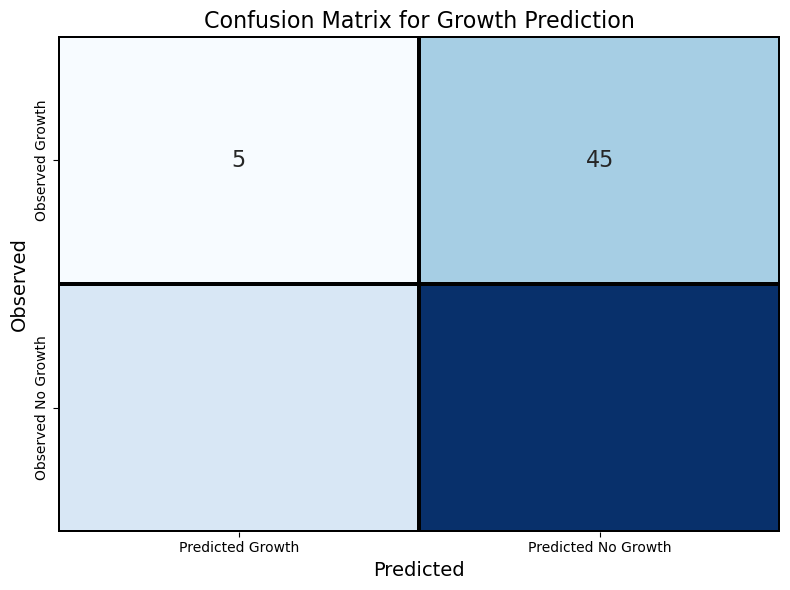

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Example confusion matrix data
confusion_matrix = np.array([[5, 45], 
                             [23, 119]])

# Create a DataFrame for better labeling
confusion_df = pd.DataFrame(confusion_matrix, 
                            index=["Observed Growth", "Observed No Growth"], 
                            columns=["Predicted Growth", "Predicted No Growth"])

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16}, linewidths=1.5, linecolor='black')

# Set labels and title
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Observed", fontsize=14)
plt.title("Confusion Matrix for Growth Prediction", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

### frequency plot

In [38]:
flatten_values = [element for element in biolog_data.values.flatten()]
# data gets flattened and rounded to only contain two number after decimal
rounded_data = [round(num, 2) for num in flatten_values]
rounded_data

[0.24,
 0.21,
 0.23,
 0.21,
 0.44,
 0.51,
 0.25,
 0.22,
 0.33,
 0.24,
 0.23,
 0.21,
 0.35,
 0.71,
 0.27,
 0.21,
 0.22,
 0.27,
 0.22,
 0.23,
 0.23,
 0.36,
 0.23,
 0.25,
 0.25,
 0.21,
 0.23,
 0.34,
 0.62,
 0.33,
 0.21,
 0.24,
 0.21,
 0.54,
 0.21,
 0.22,
 0.71,
 0.58,
 0.48,
 0.21,
 0.26,
 0.23,
 0.24,
 0.4,
 0.18,
 0.22,
 0.21,
 0.23,
 0.27,
 0.24,
 0.25,
 0.24,
 0.18,
 0.23,
 0.22,
 0.23,
 0.23,
 0.22,
 0.21,
 0.22,
 1.62,
 0.91,
 0.22,
 0.26,
 0.29,
 0.49,
 0.22,
 0.33,
 0.48,
 0.31,
 0.23,
 0.68,
 0.28,
 0.23,
 0.27,
 0.26,
 0.68,
 0.35,
 0.25,
 0.24,
 0.25,
 0.28,
 0.26,
 0.26,
 0.19,
 0.22,
 0.2,
 0.22,
 0.25,
 0.59,
 0.34,
 1.2,
 0.62,
 0.22,
 0.2,
 0.25]

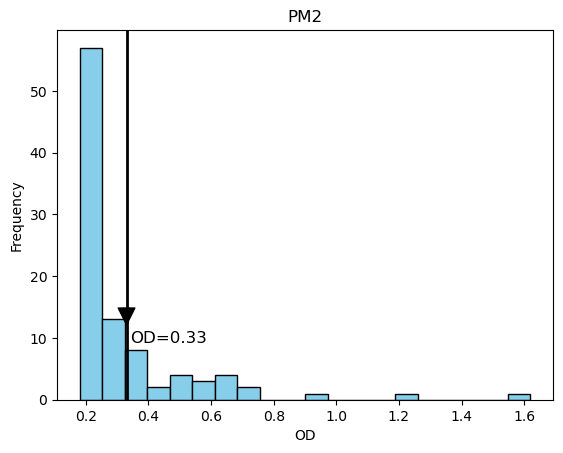

In [39]:

# Create the histogram
plt.hist(rounded_data, bins=20, color='skyblue', edgecolor='black')

# Add a vertical marker (arrow) at a specific OD value (e.g., 0.33384)
plt.axvline(x=0.33, color='black', linestyle='-', linewidth=2)
plt.annotate('', xy=(0.33, 12), xytext=(0.33, 15), 
             arrowprops=dict(facecolor='black', shrink=0.05))
od_threshold = 0.33
# Add the OD value as a text label on the plot
plt.text(od_threshold + 0.01, 10, f'OD={od_threshold:.2f}', color='black', fontsize=12, verticalalignment='center')

# Add labels and title
plt.xlabel('OD')
plt.ylabel('Frequency')
plt.title('PM2')


# Show the plot
plt.show()

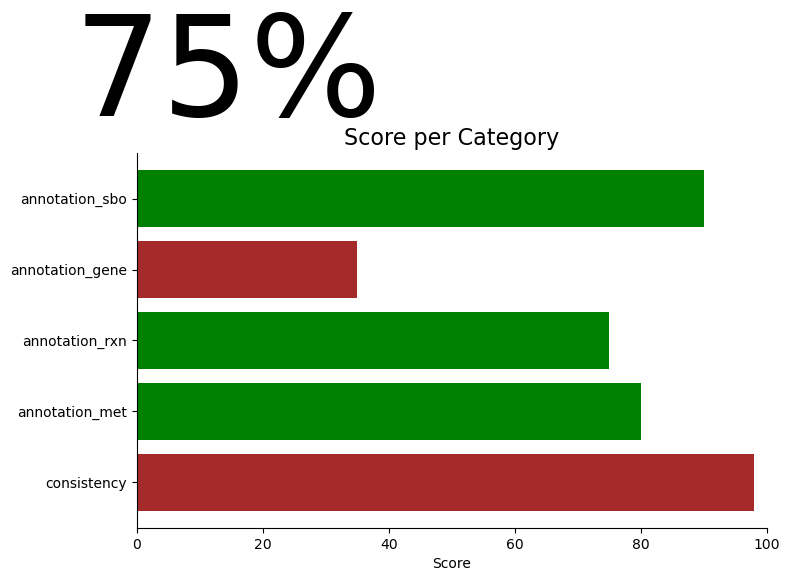

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data for the plot (sample values)
categories = ['consistency', 'annotation_met', 'annotation_rxn', 'annotation_gene', 'annotation_sbo']
scores = [55, 85, 70, 45, 90]

# Create the figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 6))

# Horizontal bar plot
ax.barh(categories, scores, color=['brown', 'green', 'green', 'brown', 'green'])

# Add a title for the percentage (for visual purpose, we take the average here, you can replace it with a real percentage)
percentage = int(np.mean(scores))
plt.text(-0.1, 1.1, f"{percentage}%", fontsize=100, color='black', transform=ax.transAxes)

# Labels and formatting
ax.set_xlabel("Score")
ax.set_xlim(0, 100)  # Set the x-axis from 0 to 100 (percent)
ax.set_title("Score per Category", fontsize=16)

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()



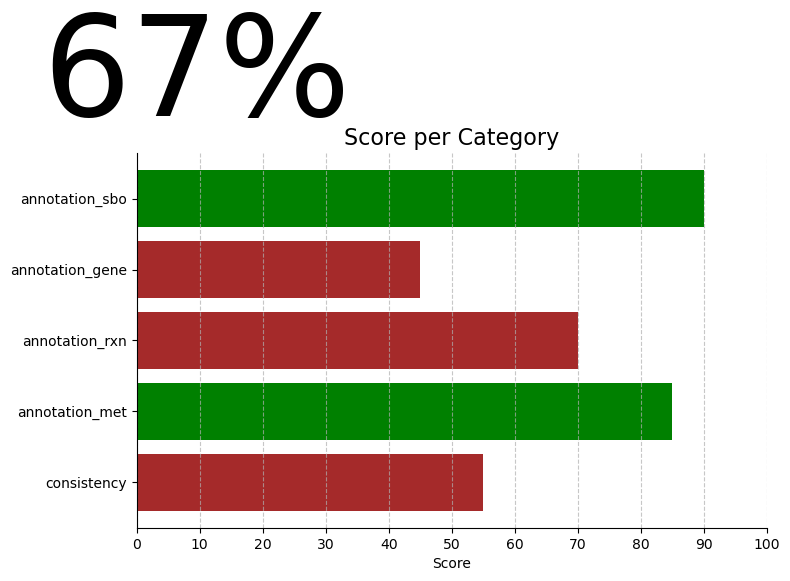

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data for the plot (sample values)
categories = ['consistency', 'annotation_met', 'annotation_rxn', 'annotation_gene', 'annotation_sbo']
scores = [55, 85, 70, 45, 90]

# Create the figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 6))

# Horizontal bar plot with specific colors
colors = ['green' if score > 70 else 'brown' for score in scores]  # Green for high, brown for low scores
ax.barh(categories, scores, color=colors)

# Add a large percentage label (88%)
percentage = 67  # Displayed score set to 88%
plt.text(-0.15, 1.1, f"{percentage}%", fontsize=100, color='black', transform=ax.transAxes)

# Labels and formatting
ax.set_xlabel("Score")
ax.set_xlim(0, 100)  # Set the x-axis from 0 to 100 (percent)
ax.set_title("Score per Category", fontsize=16)

# Customize ticks and grid for a cleaner look
ax.xaxis.set_ticks(np.arange(0, 101, 10))
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

# Remove the top and right spines for a cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()